In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load Diabetes dataset
diabetes = load_diabetes()

X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name="Disease_Progression")

print("Dataset Shape:", X.shape)

print("\nFeatures:")
display(X.head())

print("\nTarget:")
display(y.head())

Dataset Shape: (442, 10)

Features:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641



Target:


,Disease_Progression
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0


In [3]:
print("Feature Names:")
print(diabetes.feature_names)

print("\nTarget Variable:")
print("Disease progression")

print("\nMissing Values:")
print(X.isnull().sum().sum())

Feature Names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Target Variable:
Disease progression

Missing Values:
0


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 353
Testing Samples: 89


In [5]:
X_bmi = X[["bmi"]]

X_train_bmi, X_test_bmi, y_train, y_test = train_test_split(
    X_bmi,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
simple_model = LinearRegression()

simple_model.fit(X_train_bmi, y_train)

print("Intercept:", round(simple_model.intercept_, 4))
print("Slope:", round(simple_model.coef_[0], 4))

print(
    f"Equation: Disease Progression = "
    f"{simple_model.intercept_:.4f} + "
    f"({simple_model.coef_[0]:.4f} × BMI)"
)

Intercept: 152.0034
Slope: 998.5777
Equation: Disease Progression = 152.0034 + (998.5777 × BMI)


In [7]:
y_pred_simple = simple_model.predict(X_test_bmi)

print("Predicted values:")
print(y_pred_simple[:10])

Predicted values:
[145.80622687 188.85739048 147.95878505 203.92529774 131.8145987
 127.50948234 322.31599764 197.4676232   61.85645785 167.33180868]


In [8]:
mse_simple = mean_squared_error(y_test, y_pred_simple)
r2_simple = r2_score(y_test, y_pred_simple)

print("Simple Linear Regression")
print("-------------------------")
print("Mean Squared Error:", round(mse_simple, 4))
print("R² Score:", round(r2_simple, 4))

Simple Linear Regression
-------------------------
Mean Squared Error: 4061.8259
R² Score: 0.2334


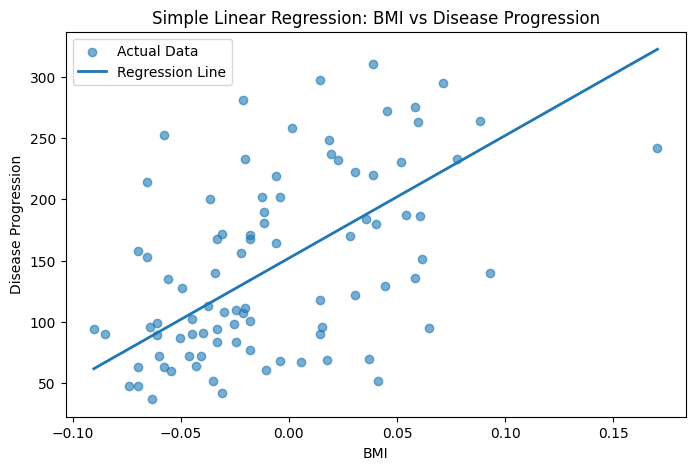

In [9]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_test_bmi,
    y_test,
    alpha=0.6,
    label="Actual Data"
)

X_sorted = X_test_bmi.sort_values("bmi")

plt.plot(
    X_sorted,
    simple_model.predict(X_sorted),
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("Simple Linear Regression: BMI vs Disease Progression")
plt.legend()
plt.show()

In [10]:
multiple_model = LinearRegression()

multiple_model.fit(X_train, y_train)

print("Intercept:", round(multiple_model.intercept_, 4))

print("\nCoefficients:")
for feature, coefficient in zip(X.columns, multiple_model.coef_):
    print(feature, ":", round(coefficient, 4))

Intercept: 151.3456

Coefficients:
age : 37.904
sex : -241.9644
bmi : 542.4288
bp : 347.7038
s1 : -931.4888
s2 : 518.0623
s3 : 163.42
s4 : 275.3179
s5 : 736.1989
s6 : 48.6707


In [11]:
y_pred_multiple = multiple_model.predict(X_test)

print("Predicted values:")
print(y_pred_multiple[:10])

Predicted values:
[139.5475584  179.51720835 134.03875572 291.41702925 123.78965872
  92.1723465  258.23238899 181.33732057  90.22411311 108.63375858]


In [12]:
mse_multiple = mean_squared_error(y_test, y_pred_multiple)
r2_multiple = r2_score(y_test, y_pred_multiple)

print("Multiple Linear Regression")
print("---------------------------")
print("Mean Squared Error:", round(mse_multiple, 4))
print("R² Score:", round(r2_multiple, 4))

Multiple Linear Regression
---------------------------
Mean Squared Error: 2900.1936
R² Score: 0.4526


In [13]:
comparison = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression"
    ],
    "MSE": [
        mse_simple,
        mse_multiple
    ],
    "R² Score": [
        r2_simple,
        r2_multiple
    ]
})

display(comparison)

,Model,MSE,R² Score
0,Simple Linear Regression,4061.825928,0.233350
1,Multiple Linear Regression,2900.193628,0.452603
